<a href="https://colab.research.google.com/github/Opsimtech/CFD-ML-model/blob/main/Flettner_PINN_ClosureStudies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flettner PINN — Closure Studies
**Study A: Physics-only failure characterisation (7 runs)**
**Study B: Sector masking robustness (4 runs)**

Re=3.6e5, α=2.0. Same validated architecture/weights as NCp8 best run.
Resume-safe: results saved to Drive after each run.
Every run records circulation Γ at r=2R (branch-selection diagnostic).

Run cells 1→2→3→4 (Study A) →5 (Study B) →6 (analysis).

In [1]:
# ── CELL 1: Parameters ───────────────────────────────────────────
from google.colab import drive
drive.mount("/content/drive", force_remount=False)
import os, numpy as np, pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size":11,"figure.dpi":120})

RE, ALPHA = 3.6e5, 2.0
NU        = 1.0/RE
R_IN, R_OUT = 0.5, 25.0

# Baseline (validated NCp8 settings)
BASE = dict(EPOCHS=6000, LR=1e-4, LAYERS=6, WIDTH=64,
            N_INT=2000, N_WALL=300, N_FF=150,
            W_PDE=100., W_VWALL=300., W_VFF=10., W_PP=50.,
            W_CP=10., W_TURB=1.)

# ── STUDY A: physics-only sweep (NCp=0 except P7) ────────────────
STUDY_A = {
 "P1_baseline":   dict(),                                   # NCp=0 reference
 "P2_wall1000":   dict(W_VWALL=1000.),                      # stronger rotation BC
 "P3_long15k":    dict(EPOCHS=15000),                       # convergence check
 "P4_big8x128":   dict(LAYERS=8, WIDTH=128),                # capacity check
 "P5_wall800":    dict(N_WALL=800, WALL_CLUSTER=True),      # wall resolution
 "P6_curriculum": dict(CURRICULUM=True),                    # alpha 0.5 -> 2.0
 "P7_oneCp":      dict(NCP_ONE=True),                       # single Cp at stagnation
}
# ── STUDY B: sector masking (full 30 pts minus a sector) ─────────
STUDY_B = {
 "M1_windward":  (315., 45.),    # hide 315..360 + 0..45
 "M2_suction":   (60., 150.),    # hide suction peak
 "M3_leeward":   (135., 225.),   # hide wake side
 "M4_random50":  "random",       # hide random 50%
}

DATA_DIR = "/content/drive/MyDrive/P-PINN"
OUT_DIR  = "/content/drive/MyDrive/PINN_outputs"
os.makedirs(OUT_DIR, exist_ok=True)
RESULTS_FILE = f"{OUT_DIR}/closure_studies_alpha{ALPHA}.json"

print(f"TF {tf.__version__} | GPU: {bool(tf.config.list_physical_devices('GPU'))}")
print(f"Study A runs: {list(STUDY_A.keys())}")
print(f"Study B runs: {list(STUDY_B.keys())}")


# ── Drive-safe saving (mount dies silently in long sessions) ─────
import json as _json_ss, shutil as _shutil_ss

def drive_alive():
    return os.path.ismount("/content/drive")

def ensure_drive():
    if not drive_alive():
        print("  ⚠ Drive mount lost — remounting...")
        from google.colab import drive as _drv
        _drv.mount("/content/drive", force_remount=True)
        os.makedirs(OUT_DIR, exist_ok=True)

def safe_save(results):
    """Local backup + verified Drive write with fsync + read-back."""
    with open("/content/closure_backup.json","w") as f:
        _json_ss.dump(results,f); f.flush(); os.fsync(f.fileno())
    ensure_drive()
    with open(RESULTS_FILE,"w") as f:
        _json_ss.dump(results,f,indent=2); f.flush(); os.fsync(f.fileno())
    with open(RESULTS_FILE) as f:          # read-back verification
        n=len(_json_ss.load(f))
    sz=os.path.getsize(RESULTS_FILE)/1024
    print(f"  💾 verified on Drive: {n} runs, {sz:.0f} KB ✓")

def safe_save_weights(model, path):
    tmp="/content/_tmp.weights.h5"
    model.save_weights(tmp)
    ensure_drive()
    _shutil_ss.copy(tmp, path)
    if os.path.exists(path) and os.path.getsize(path)>0:
        print(f"  💾 weights verified: {os.path.basename(path)} ✓")
    else:
        print(f"  ✗ WEIGHTS SAVE FAILED: {path}")


Mounted at /content/drive
TF 2.20.0 | GPU: False
Study A runs: ['P1_baseline', 'P2_wall1000', 'P3_long15k', 'P4_big8x128', 'P5_wall800', 'P6_curriculum', 'P7_oneCp']
Study B runs: ['M1_windward', 'M2_suction', 'M3_leeward', 'M4_random50']


In [2]:
# ── CELL 2: Load data ────────────────────────────────────────────
RE_COL_MAP = {1.8e5:{0,12,24,36,48,60},2.5e5:{3,15,27,39,51,63,69,75,81,87,93},
              3.6e5:{6,18,30,42,54,72,78,84,90,96},1.0e6:{9,21,33,45,57,66}}

def load_cp(folder, re_t, a_t, tol=0.1):
    for nm in ["CP_data.xlsx","CP data.xlsx"]:
        p=os.path.join(folder,nm)
        if os.path.exists(p): break
    raw=pd.read_excel(p,sheet_name="Master Data",header=None); row0=raw.iloc[0]
    for col in range(0,len(row0)-1,3):
        lab=str(row0.iloc[col])
        if "k =" not in lab: continue
        try: kv=float(lab.split(",")[0].replace("k =","").strip())
        except: continue
        if abs(kv-a_t)>tol: continue
        rm=None
        for rv,cs in RE_COL_MAP.items():
            if col in cs: rm=rv; break
        if rm is None or abs(rm-re_t)>re_t*0.1: continue
        th=pd.to_numeric(raw.iloc[2:,col],errors="coerce").values
        cp=pd.to_numeric(raw.iloc[2:,col+1],errors="coerce").values
        m=~np.isnan(th)&~np.isnan(cp)
        if m.sum()<3: continue
        return th[m].astype(np.float32), cp[m].astype(np.float32)
    raise ValueError("no data")

def load_cl_cd(folder, re_t):
    sheet={1.8e5:"Re=1.8e5",2.5e5:"Re=2.5e5",3.6e5:"Re=3.6e5",
           5.5e5:"Re=5.5e5",1.0e6:"Re=1e6"}[min({1.8e5,2.5e5,3.6e5,5.5e5,1.0e6},
           key=lambda r:abs(r-re_t))]
    for nm in ["CL_data.xlsx","CL data.xlsx"]:
        p=os.path.join(folder,nm)
        if os.path.exists(p): clp=p; break
    for nm in ["CD_data.xlsx","CD data.xlsx"]:
        p=os.path.join(folder,nm)
        if os.path.exists(p): cdp=p; break
    dcl=pd.read_excel(clp,sheet_name=sheet,header=None)
    dcd=pd.read_excel(cdp,sheet_name=sheet,header=None)
    dcl.columns=["alpha","CL"]+list(dcl.columns[2:])
    dcd.columns=["alpha","CD"]+list(dcd.columns[2:])
    return (dcl["alpha"].dropna().values.astype(np.float32),
            dcl["CL"].dropna().values.astype(np.float32),
            dcd["alpha"].dropna().values.astype(np.float32),
            dcd["CD"].dropna().values.astype(np.float32))

theta_exp, cp_exp = load_cp(DATA_DIR, RE, ALPHA)
al_cl,CL_e,al_cd,CD_e = load_cl_cd(DATA_DIR, RE)
tol=0.25
cl_ref=float(CL_e[np.abs(al_cl-ALPHA)<tol].mean())
cd_ref=float(CD_e[np.abs(al_cd-ALPHA)<tol].mean())

# Kutta-Joukowski with CCW-positive circulation: L' = -rho*U*Gamma.
# CW rotation produces lift in +y (CL>0), so the physical circulation is
# NEGATIVE in the CCW convention used by compute_circulation():
# Gamma_exp = -0.5*CL*D
GAMMA_EXP = -0.5*cl_ref*1.0
print(f"Cp: {len(theta_exp)} pts | CL_exp={cl_ref:.3f} CD_exp={cd_ref:.3f}")
print(f"Kutta-Joukowski circulation estimate: Gamma_exp = {GAMMA_EXP:.3f}")

# Stagnation angle (max Cp) for P7 single-point run
STAG_THETA = float(theta_exp[np.argmax(cp_exp)])
print(f"Stagnation angle (for P7 single point): {STAG_THETA:.1f}°")


Cp: 30 pts | CL_exp=5.917 CD_exp=1.745
Kutta-Joukowski circulation estimate: Gamma_exp = -2.959
Stagnation angle (for P7 single point): 331.1°


In [3]:
# ── CELL 3: Model builder and shared functions ───────────────────
import tensorflow as tf

def build_model(layers=6, width=64):
    tf.keras.backend.clear_session()
    inp=tf.keras.Input(shape=(3,))
    h=inp
    for i in range(layers):
        h=tf.keras.layers.Dense(width,activation="tanh")(h)
    uvp=tf.keras.layers.Dense(3,activation=None)(h)
    ko =tf.keras.layers.Dense(2,activation="softplus")(h)
    return tf.keras.Model(inp,[uvp,ko])

def get_uvp(o): return o[0]
def get_ko(o):  return o[1]
def mse(a,b=0.0): return tf.reduce_mean(tf.square(a-b))

C = dict(NU=tf.constant(float(NU),tf.float32),BSTAR=tf.constant(.09,tf.float32),
    BETA2=tf.constant(.0828,tf.float32),SK2=tf.constant(1.,tf.float32),
    SO2=tf.constant(.856,tf.float32),
    GAM2=tf.constant(.0828/.09-.856*.41**2/.09**.5,tf.float32),
    EPS=tf.constant(1e-8,tf.float32),KW=tf.constant(0.,tf.float32),
    OW=tf.constant(60.*float(NU),tf.float32),
    KI=tf.constant(1.5e-4,tf.float32),OI=tf.constant(2.,tf.float32))

def make_input(x,y,alpha):
    a=np.full_like(x,float(alpha)/5.0,dtype=np.float32)
    return tf.constant(np.hstack([x,y,a]))

def sample_interior(n, wall_cluster=False):
    th=np.random.uniform(0,2*np.pi,n).astype(np.float32)
    if wall_cluster:
        # 50% of points within r<2R (stronger near-wall resolution)
        n1=n//2
        r1=np.exp(np.random.uniform(np.log(R_IN),np.log(2*R_IN),n1))
        r2=np.exp(np.random.uniform(np.log(2*R_IN),np.log(R_OUT),n-n1))
        r=np.concatenate([r1,r2]).astype(np.float32)
    else:
        r=np.exp(np.random.uniform(np.log(R_IN),np.log(R_OUT),n)).astype(np.float32)
    return (r*np.cos(th)).reshape(-1,1),(r*np.sin(th)).reshape(-1,1)

def sample_wall(n):
    th=np.linspace(0,2*np.pi,n,endpoint=False,dtype=np.float32)
    return (-R_IN*np.cos(th)).reshape(-1,1),(+R_IN*np.sin(th)).reshape(-1,1)

def sample_ff(n):
    th=np.linspace(0,2*np.pi,n,endpoint=False,dtype=np.float32)
    return (R_OUT*np.cos(th)).reshape(-1,1),(R_OUT*np.sin(th)).reshape(-1,1)

def compute_circulation(model, alpha, r_circ=1.0, n=512):
    """Gamma = closed-loop integral of velocity at r=2*R_IN (r_circ=1.0)."""
    th=np.linspace(0,2*np.pi,n,endpoint=False,dtype=np.float32)
    x=(r_circ*np.cos(th)).reshape(-1,1); y=(r_circ*np.sin(th)).reshape(-1,1)
    o=get_uvp(model(make_input(x,y,alpha),training=False)).numpy()
    u,v=o[:,0],o[:,1]
    # tangential unit vector along CCW loop: (-sin, cos)
    ut=-u*np.sin(th)+v*np.cos(th)
    return float(np.sum(ut)*r_circ*2*np.pi/n)

def evaluate(model, alpha, mask_range=None):
    """Returns full metrics dict. If mask_range given, also masked-sector MAE."""
    def pref(n=256):
        th=np.linspace(0,2*np.pi,n,dtype=np.float32)
        xy=make_input((R_OUT*np.cos(th)).reshape(-1,1),
                      (R_OUT*np.sin(th)).reshape(-1,1),alpha)
        return float(get_uvp(model(xy,training=False)).numpy()[:,2].mean())
    th_deg=np.linspace(0,360,360,dtype=np.float32)
    th_rad=np.radians(th_deg)
    x=(-R_IN*np.cos(th_rad)).reshape(-1,1); y=(+R_IN*np.sin(th_rad)).reshape(-1,1)
    uvp=get_uvp(model(make_input(x,y,alpha),training=False)).numpy()
    pr=pref()
    Cp_raw=2.*(uvp[:,2]-pr)
    Cp=Cp_raw+(float(cp_exp.max())-Cp_raw.max())
    Cp_i=np.interp(theta_exp,th_deg,Cp)
    mae_all=float(np.mean(np.abs(Cp_i-cp_exp)))
    res=dict(mae=mae_all, Cp_pred=Cp.tolist(), th_deg=th_deg.tolist(),
             gamma=compute_circulation(model,alpha),            # r=1 (=2R): near-wall swirl
             gamma_r5=compute_circulation(model,alpha,r_circ=5.0))  # r=5 (=10R): outer-flow bound circulation
    # forces
    n_f=512; dth=2*np.pi/n_f
    thf=np.linspace(0,2*np.pi,n_f,endpoint=False,dtype=np.float32)
    xf=(-R_IN*np.cos(thf)).reshape(-1,1); yf=(+R_IN*np.sin(thf)).reshape(-1,1)
    nx=xf/R_IN; ny=yf/R_IN
    p_shift=(float(cp_exp.max())-Cp_raw.max())/2.
    def uv(xp,yp):
        o=get_uvp(model(make_input(xp,yp,alpha),training=False)).numpy()
        return o[:,0:1],o[:,1:2],o[:,2:3]
    u0,v0,p0=uv(xf,yf); p0=p0-pr-p_shift
    uxp,vxp,_=uv(xf+1e-3,yf); uxm,vxm,_=uv(xf-1e-3,yf)
    uyp,vyp,_=uv(xf,yf+1e-3); uym,vym,_=uv(xf,yf-1e-3)
    du_dx=(uxp-uxm)/2e-3; du_dy=(uyp-uym)/2e-3
    dv_dx=(vxp-vxm)/2e-3; dv_dy=(vyp-vym)/2e-3
    nu_v=float(NU)
    txx=2*nu_v*du_dx; txy=nu_v*(du_dy+dv_dx); tyy=2*nu_v*dv_dy
    res["CL"]=float((np.sum(-p0*ny*R_IN*dth)+np.sum((txy*nx+tyy*ny)*R_IN*dth))/.5)
    res["CD"]=float((np.sum(-p0*nx*R_IN*dth)+np.sum((txx*nx+txy*ny)*R_IN*dth))/.5)
    # masked-sector MAE if applicable
    if mask_range is not None:
        lo,hi=mask_range
        if lo<hi: in_mask=(theta_exp>=lo)&(theta_exp<=hi)
        else:     in_mask=(theta_exp>=lo)|(theta_exp<=hi)   # wraps 360
        if in_mask.sum()>0:
            res["mae_masked"]=float(np.mean(np.abs(Cp_i[in_mask]-cp_exp[in_mask])))
            res["mae_observed"]=float(np.mean(np.abs(Cp_i[~in_mask]-cp_exp[~in_mask])))
    return res

print("Shared functions ready ✓")


def plot_flow_field(model, name, alpha=ALPHA):
    """|u| + streamlines and Cp contour. Saved to Drive immediately."""
    XMIN,XMAX,YMIN,YMAX,NXg,NYg = -2.5,4.5,-2.5,2.5,300,220
    xg=np.linspace(XMIN,XMAX,NXg,dtype=np.float32)
    yg=np.linspace(YMIN,YMAX,NYg,dtype=np.float32)
    X,Y=np.meshgrid(xg,yg)
    pts=np.stack([X.ravel(),Y.ravel()],axis=1)
    U=np.empty(len(pts),np.float32); V=np.empty(len(pts),np.float32)
    P=np.empty(len(pts),np.float32)
    for i0 in range(0,len(pts),20000):
        sl=slice(i0,min(i0+20000,len(pts)))
        o=get_uvp(model(make_input(pts[sl,0:1],pts[sl,1:2],alpha),training=False)).numpy()
        U[sl],V[sl],P[sl]=o[:,0],o[:,1],o[:,2]
    U=U.reshape(NYg,NXg); V=V.reshape(NYg,NXg); P=P.reshape(NYg,NXg)
    thf=np.linspace(0,2*np.pi,256,dtype=np.float32)
    pref=float(get_uvp(model(make_input((R_OUT*np.cos(thf)).reshape(-1,1),
        (R_OUT*np.sin(thf)).reshape(-1,1),alpha),training=False)).numpy()[:,2].mean())
    ths=np.radians(np.linspace(0,360,360,dtype=np.float32))
    ps=get_uvp(model(make_input((-R_IN*np.cos(ths)).reshape(-1,1),
        (+R_IN*np.sin(ths)).reshape(-1,1),alpha),training=False)).numpy()[:,2]
    shift=float(cp_exp.max())-float((2.*(ps-pref)).max())
    Cpf=2.*(P-pref)+shift
    inside=np.sqrt(X**2+Y**2)<R_IN*1.001
    U=np.where(inside,np.nan,U); V=np.where(inside,np.nan,V)
    Cpf=np.where(inside,np.nan,Cpf)
    sp=np.sqrt(U**2+V**2)
    fig,axes=plt.subplots(1,2,figsize=(13,4.5))
    c1=axes[0].contourf(X,Y,sp,levels=41,cmap="viridis")
    axes[0].streamplot(X[0,:],Y[:,0],U,V,color="w",linewidth=.7,
                       density=1.4,arrowsize=.8)
    axes[0].add_patch(plt.Circle((0,0),R_IN,color="lightgrey",ec="k",zorder=6))
    axes[0].annotate("",xy=(0.30,-0.22),xytext=(0.30,0.22),
        arrowprops=dict(arrowstyle="->",lw=1.5,color="k"),zorder=7)
    plt.colorbar(c1,ax=axes[0],label="|u|/U∞",shrink=.9)
    axes[0].set_aspect("equal"); axes[0].set_xlabel("x/D"); axes[0].set_ylabel("y/D")
    axes[0].set_title("Velocity magnitude + streamlines")
    lv=np.linspace(np.nanpercentile(Cpf,1),np.nanpercentile(Cpf,99.5),41)
    c2=axes[1].contourf(X,Y,Cpf,levels=lv,cmap="RdBu_r")
    axes[1].add_patch(plt.Circle((0,0),R_IN,color="lightgrey",ec="k",zorder=6))
    plt.colorbar(c2,ax=axes[1],label="Cp",shrink=.9)
    axes[1].set_aspect("equal"); axes[1].set_xlabel("x/D"); axes[1].set_ylabel("y/D")
    axes[1].set_title("Pressure coefficient")
    plt.suptitle(f"Flow field — {name} | α={alpha}, Re={RE:.1e}",fontweight="bold")
    plt.tight_layout()
    ensure_drive()
    plt.savefig(f"{OUT_DIR}/field_{name}.png",bbox_inches="tight",dpi=150)
    plt.show()
    print(f"  🖼 field_{name}.png saved ✓")


Shared functions ready ✓


In [4]:
# ── RECOVERY CELL (run once): inject results read from screenshots ──
# The previous session completed P1,P2,P4,P5,P6 but the Drive mount had
# died, so the JSON was lost. Scalar metrics were recovered from the
# printed output. These entries lack Cp_pred/gamma_hist/weights
# (marked recovered=True); Cell 6 skips their curve plots.
import json as _json, os as _os

RECOVERED = {
 "P1_baseline":   dict(mae=3.392, gamma=-13.059, CL=0.016,  CD=-0.002),
 "P2_wall1000":   dict(mae=3.227, gamma=-8.494,  CL=0.059,  CD=-0.244),
 "P4_big8x128":   dict(mae=3.391, gamma=-11.935, CL=0.014,  CD=-0.028),
 "P5_wall800":    dict(mae=3.383, gamma=-13.954, CL=-0.001, CD=-0.033),
 "P6_curriculum": dict(mae=3.375, gamma=-10.679, CL=0.043,  CD=0.000),
}

if _os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE) as f: all_results=_json.load(f)
else:
    all_results={}

added=0
for rid, vals in RECOVERED.items():
    if rid not in all_results:
        all_results[rid]={**vals, "study":"A", "recovered":True,
                          "config":{k:str(v) for k,v in STUDY_A[rid].items()}}
        added+=1
if added:
    safe_save(all_results)
print(f"Recovery: {added} entries injected, {len(all_results)} total.")
print("Cell 4 will now skip these and run only P3_long15k and P7_oneCp.")


Recovery: 0 entries injected, 10 total.
Cell 4 will now skip these and run only P3_long15k and P7_oneCp.


In [5]:
# ── CELL 4: Training function + STUDY A runs ─────────────────────
import time, json as _json, os as _os

if _os.path.exists(RESULTS_FILE):
    with open(RESULTS_FILE) as f: all_results=_json.load(f)
    print(f"Resuming — {len(all_results)} runs done: {list(all_results.keys())}")
else:
    all_results={}

def train_run(cfg, cp_theta_train, cp_val_train, run_label,
              curriculum=False):
    """One full training. cp_theta_train may be empty (physics only)."""
    p={**BASE, **cfg}
    has_cp=len(cp_theta_train)>0
    model=build_model(p["LAYERS"], p["WIDTH"])
    opt=tf.keras.optimizers.Adam(p["LR"])
    EPS_FD=1e-3
    wall_cluster=p.get("WALL_CLUSTER",False)

    Omega=float(ALPHA/R_IN)
    xw,yw=sample_wall(p["N_WALL"]); xff,yff=sample_ff(p["N_FF"])
    xw_tf=make_input(xw,yw,ALPHA); xff_tf=make_input(xff,yff,ALPHA)
    u_w=tf.constant((Omega*yw).astype(np.float32))
    v_w=tf.constant((-Omega*xw).astype(np.float32))

    if has_cp:
        thr=np.radians(cp_theta_train).astype(np.float32)
        xs=(-R_IN*np.cos(thr)).reshape(-1,1); ys=(+R_IN*np.sin(thr)).reshape(-1,1)
        xy_s=make_input(xs,ys,ALPHA)
        cp_t=tf.constant(np.asarray(cp_val_train,dtype=np.float32).reshape(-1,1))

    # curriculum: first 2000 epochs at alpha=0.5, then warm-start alpha=2
    alpha_schedule=(lambda ep: 0.5 if (curriculum and ep<2000) else ALPHA)

    best_loss,best_w=np.inf,None
    t0=time.time(); gamma_hist=[]
    EPOCHS=p["EPOCHS"]

    for ep in range(EPOCHS):
        a_now=alpha_schedule(ep)
        if curriculum and ep in (0,2000):
            # rebuild wall targets for current alpha
            Om=float(a_now/R_IN)
            u_w=tf.constant((Om*yw).astype(np.float32))
            v_w=tf.constant((-Om*xw).astype(np.float32))
            xw_tf=make_input(xw,yw,a_now); xff_tf=make_input(xff,yff,a_now)
            if has_cp: xy_s=make_input(xs,ys,a_now)

        x_i,y_i=sample_interior(p["N_INT"], wall_cluster)
        xy_var=tf.Variable(make_input(x_i,y_i,a_now),trainable=False,dtype=tf.float32)
        tr=float(min(1.,max(0.,(ep-1000)/1000.)))
        tr_tf=tf.constant(tr,tf.float32)

        with tf.GradientTape() as tape:
            with tf.GradientTape(watch_accessed_variables=False,persistent=True) as it:
                it.watch(xy_var)
                out=model(xy_var,training=True); uvp=get_uvp(out)
                u,v,pp=uvp[:,0:1],uvp[:,1:2],uvp[:,2:3]
                if tr>0:
                    ko=get_ko(out); k=ko[:,0:1]+C["EPS"]; om=ko[:,1:2]+C["EPS"]
            du=it.gradient(u,xy_var); dv=it.gradient(v,xy_var); dp=it.gradient(pp,xy_var)
            du_dx,du_dy=du[:,0:1],du[:,1:2]
            dv_dx,dv_dy=dv[:,0:1],dv[:,1:2]
            dp_dx,dp_dy=dp[:,0:1],dp[:,1:2]
            del it
            nu_t=tr_tf*tf.clip_by_value(k/(om+C["EPS"]),0.,.1) if tr>0 else tf.constant(0.)
            nu_eff=C["NU"]+nu_t
            NI=p["N_INT"]
            dX=tf.constant(np.hstack([np.full((NI,1),EPS_FD),np.zeros((NI,1)),np.zeros((NI,1))]).astype(np.float32))
            dY=tf.constant(np.hstack([np.zeros((NI,1)),np.full((NI,1),EPS_FD),np.zeros((NI,1))]).astype(np.float32))
            oxp=model(xy_var+dX,training=True); oxm=model(xy_var-dX,training=True)
            oyp=model(xy_var+dY,training=True); oym=model(xy_var-dY,training=True)
            uxp,uxm,uyp,uym=get_uvp(oxp),get_uvp(oxm),get_uvp(oyp),get_uvp(oym)
            ie2=1./EPS_FD**2
            d2u_dx2=(uxp[:,0:1]-2*u+uxm[:,0:1])*ie2; d2u_dy2=(uyp[:,0:1]-2*u+uym[:,0:1])*ie2
            d2v_dx2=(uxp[:,1:2]-2*v+uxm[:,1:2])*ie2; d2v_dy2=(uyp[:,1:2]-2*v+uym[:,1:2])*ie2
            r_c=du_dx+dv_dy
            r_x=u*du_dx+v*du_dy+dp_dx-nu_eff*(d2u_dx2+d2u_dy2)
            r_y=u*dv_dx+v*dv_dy+dp_dy-nu_eff*(d2v_dx2+d2v_dy2)
            loss_pde=mse(r_c)+mse(r_x)+mse(r_y)
            loss_turb=tf.constant(0.)
            if tr>0:
                kxp,kxm=get_ko(oxp),get_ko(oxm); kyp,kym=get_ko(oyp),get_ko(oym)
                iv=.5/EPS_FD
                dk_dx=(kxp[:,0:1]-kxm[:,0:1])*iv; dk_dy=(kyp[:,0:1]-kym[:,0:1])*iv
                do_dx=(kxp[:,1:2]-kxm[:,1:2])*iv; do_dy=(kyp[:,1:2]-kym[:,1:2])*iv
                d2k_x=(kxp[:,0:1]-2*k+kxm[:,0:1])*ie2; d2k_y=(kyp[:,0:1]-2*k+kym[:,0:1])*ie2
                d2o_x=(kxp[:,1:2]-2*om+kxm[:,1:2])*ie2; d2o_y=(kyp[:,1:2]-2*om+kym[:,1:2])*ie2
                S2=2*(du_dx**2+dv_dy**2)+(du_dy+dv_dx)**2
                Pk=tf.clip_by_value(nu_t*S2,0.,20.*C["BSTAR"]*k*om)
                nk=C["NU"]+C["SK2"]*nu_t; no=C["NU"]+C["SO2"]*nu_t
                crs=2.*C["SO2"]/(om+C["EPS"])*(dk_dx*do_dx+dk_dy*do_dy)
                rk=u*dk_dx+v*dk_dy-Pk+C["BSTAR"]*om*k-nk*(d2k_x+d2k_y)
                ro=u*do_dx+v*do_dy-C["GAM2"]*(om/(k+C["EPS"]))*Pk+C["BETA2"]*om**2-no*(d2o_x+d2o_y)-crs
                loss_turb=tr_tf*(mse(tf.clip_by_value(rk,-100.,100.))+mse(tf.clip_by_value(ro,-100.,100.)))
            ow=model(xw_tf,training=True); uw=get_uvp(ow)
            loss_wall=mse(uw[:,0:1],u_w)+mse(uw[:,1:2],v_w)
            if tr>0:
                kw=get_ko(ow)
                loss_wall+=tr_tf*(mse(kw[:,0:1],C["KW"])+mse(kw[:,1:2],C["OW"]))
            off=model(xff_tf,training=True); uff=get_uvp(off)
            loss_ff=mse(uff[:,0:1],1.)+mse(uff[:,1:2])
            pfm=tf.reduce_mean(uff[:,2:3]); loss_pp=tf.square(pfm)
            if tr>0:
                kff=get_ko(off)
                loss_ff+=tr_tf*(mse(kff[:,0:1],C["KI"])+mse(kff[:,1:2],C["OI"]))
            loss_cp=tf.constant(0.)
            if has_cp:
                oc=model(xy_s,training=True); uc=get_uvp(oc)
                loss_cp=mse(2.*(uc[:,2:3]-pfm),cp_t)
            loss=(p["W_PDE"]*loss_pde+p["W_VWALL"]*loss_wall+p["W_VFF"]*loss_ff+
                  p["W_PP"]*loss_pp+p["W_CP"]*loss_cp+p["W_TURB"]*loss_turb)
        g=tape.gradient(loss,model.trainable_variables)
        g,_=tf.clip_by_global_norm(g,5.)
        opt.apply_gradients(zip(g,model.trainable_variables))
        L=float(loss)
        if not np.isnan(L) and L<best_loss: best_loss=L; best_w=model.get_weights()
        if ep%1000==0:
            gam=compute_circulation(model,a_now)
            g5 =compute_circulation(model,a_now,r_circ=5.0)
            gamma_hist.append((ep,gam,g5))
            print(f"  ep {ep:5d} L={L:.3f} pde={float(loss_pde):.4f} "
                  f"wall={float(loss_wall):.4f} Γ1={gam:+.2f} Γ5={g5:+.2f} "
                  f"(tgt {GAMMA_EXP:.2f}) | {time.time()-t0:.0f}s")
        if ep==int(EPOCHS*0.5): opt.learning_rate.assign(3e-5)
    if best_w: model.set_weights(best_w)
    safe_save_weights(model, f"{OUT_DIR}/closure_{run_label}.weights.h5")
    return model, gamma_hist, (time.time()-t0)/60.

# ── STUDY A execution ─────────────────────────────────────────────
for run_id, cfg in STUDY_A.items():
    if run_id in all_results:
        print(f"✓ SKIP {run_id}"); continue
    print(f"\n{'='*55}\n  STUDY A: {run_id}\n{'='*55}")
    curriculum = cfg.pop("CURRICULUM", False)
    ncp_one    = cfg.pop("NCP_ONE",   False)
    if ncp_one:
        th_train=np.array([STAG_THETA],dtype=np.float32)
        cp_train=np.interp(th_train,theta_exp,cp_exp)
        print(f"  Single Cp point at stagnation θ={STAG_THETA:.0f}°")
    else:
        th_train=np.array([],dtype=np.float32); cp_train=np.array([],dtype=np.float32)
    model,ghist,mins=train_run(cfg, th_train, cp_train, run_id, curriculum)
    res=evaluate(model, ALPHA)
    res["gamma_hist"]=ghist; res["elapsed"]=mins; res["study"]="A"
    res["config"]={k:(v if not isinstance(v,bool) else str(v)) for k,v in cfg.items()}
    all_results[run_id]=res
    safe_save(all_results)
    plot_flow_field(model, run_id)
    print(f"  ✓ {run_id}: MAE={res['mae']:.3f} Γ1={res['gamma']:+.3f} "
          f"Γ5={res['gamma_r5']:+.3f} (exp {GAMMA_EXP:.2f}) "
          f"CL={res['CL']:.3f} CD={res['CD']:.3f}")
print("\nSTUDY A COMPLETE")


Resuming — 10 runs done: ['P1_baseline', 'P2_wall1000', 'P3_long15k', 'P4_big8x128', 'P5_wall800', 'P6_curriculum', 'P7_oneCp', 'M1_windward', 'M2_suction', 'M3_leeward']
✓ SKIP P1_baseline
✓ SKIP P2_wall1000
✓ SKIP P3_long15k
✓ SKIP P4_big8x128
✓ SKIP P5_wall800
✓ SKIP P6_curriculum
✓ SKIP P7_oneCp

STUDY A COMPLETE


✓ SKIP M1_windward
✓ SKIP M2_suction
✓ SKIP M3_leeward

  STUDY B: M4_random50
  Training on 16/30 points; hidden sector: M4_random50 (14 pts)


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['dense_7/kernel', 'dense_7/bias'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


  ep     0 L=1281.604 pde=0.1728 wall=3.8510 Γ1=-0.74 Γ5=-7.30 (tgt -2.96) | 0s
  ep  1000 L=15.922 pde=0.0827 wall=0.0075 Γ1=-3.34 Γ5=+1.97 (tgt -2.96) | 260s
  ep  2000 L=18.232 pde=0.0581 wall=0.0049 Γ1=-3.73 Γ5=-0.39 (tgt -2.96) | 565s
  ep  3000 L=2.827 pde=0.0211 wall=0.0007 Γ1=-4.59 Γ5=+0.21 (tgt -2.96) | 875s
  ep  4000 L=1.894 pde=0.0147 wall=0.0004 Γ1=-4.71 Γ5=-0.11 (tgt -2.96) | 1191s
  ep  5000 L=1.468 pde=0.0118 wall=0.0002 Γ1=-4.75 Γ5=-0.54 (tgt -2.96) | 1506s
  💾 weights verified: closure_M4_random50.weights.h5 ✓
  💾 verified on Drive: 11 runs, 208 KB ✓


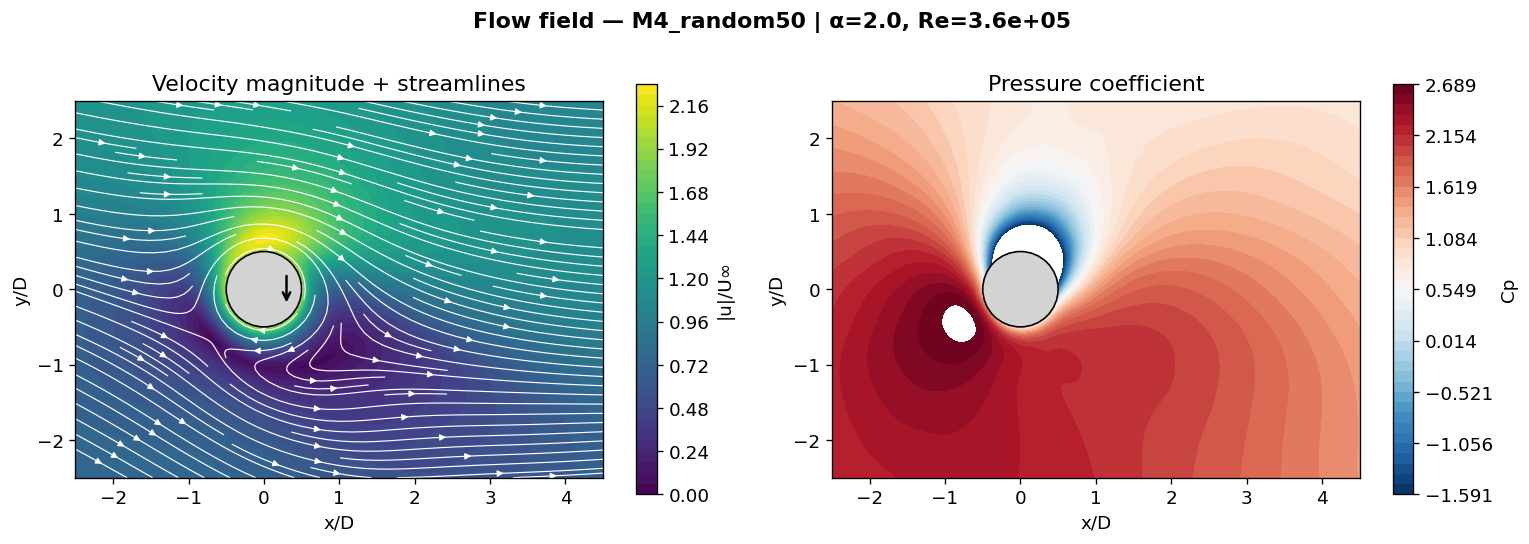

  🖼 field_M4_random50.png saved ✓
  ✓ M4_random50: MAE_all=0.165 MAE_masked=0.208 MAE_obs=0.127 CL=5.018 CD=1.706

STUDY B COMPLETE


In [6]:
import json as _json

import numpy as np # Ensure np is explicitly imported

def plot_flow_field(model, name, alpha=ALPHA):
    """|u| + streamlines and Cp contour. Saved to Drive immediately."""
    XMIN,XMAX,YMIN,YMAX,NXg,NYg = -2.5,4.5,-2.5,2.5,300,220
    xg=np.linspace(XMIN,XMAX,NXg,dtype=np.float64) # Changed to float64
    yg=np.linspace(YMIN,YMAX,NYg,dtype=np.float64) # Changed to float64
    X,Y=np.meshgrid(xg,yg)
    pts=np.stack([X.ravel(),Y.ravel()],axis=1)
    U=np.empty(len(pts),np.float32); V=np.empty(len(pts),np.float32)
    P=np.empty(len(pts),np.float32)
    for i0 in range(0,len(pts),20000):
        sl=slice(i0,min(i0+20000,len(pts)))
        o=get_uvp(model(make_input(pts[sl,0:1],pts[sl,1:2],alpha),training=False)).numpy()
        U[sl],V[sl],P[sl]=o[:,0],o[:,1],o[:,2]
    U=U.reshape(NYg,NXg); V=V.reshape(NYg,NXg); P=P.reshape(NYg,NXg)
    thf=np.linspace(0,2*np.pi,256,dtype=np.float32)
    pref=float(get_uvp(model(make_input((R_OUT*np.cos(thf)).reshape(-1,1),
        (R_OUT*np.sin(thf)).reshape(-1,1),alpha),training=False)).numpy()[:,2].mean())
    ths=np.radians(np.linspace(0,360,360,dtype=np.float32))
    ps=get_uvp(model(make_input((-R_IN*np.cos(ths)).reshape(-1,1),
        (+R_IN*np.sin(ths)).reshape(-1,1),alpha),training=False)).numpy()[:,2]
    shift=float(cp_exp.max())-float((2.*(ps-pref)).max())
    Cpf=2.*(P-pref)+shift
    inside=np.sqrt(X**2+Y**2)<R_IN*1.001
    U=np.where(inside,np.nan,U); V=np.where(inside,np.nan,V)
    Cpf=np.where(inside,np.nan,Cpf)
    sp=np.sqrt(U**2+V**2)
    fig,axes=plt.subplots(1,2,figsize=(13,4.5))
    c1=axes[0].contourf(X,Y,sp,levels=41,cmap="viridis")
    axes[0].streamplot(X[0,:],Y[:,0],U,V,color="w",linewidth=.7,
                       density=1.4,arrowsize=.8)
    axes[0].add_patch(plt.Circle((0,0),R_IN,color="lightgrey",ec="k",zorder=6))
    axes[0].annotate("",xy=(0.30,-0.22),xytext=(0.30,0.22),
        arrowprops=dict(arrowstyle="->",lw=1.5,color="k"),zorder=7)
    plt.colorbar(c1,ax=axes[0],label="|u|/U∞",shrink=.9)
    axes[0].set_aspect("equal"); axes[0].set_xlabel("x/D"); axes[0].set_ylabel("y/D")
    axes[0].set_title("Velocity magnitude + streamlines")
    lv=np.linspace(np.nanpercentile(Cpf,1),np.nanpercentile(Cpf,99.5),41)
    c2=axes[1].contourf(X,Y,Cpf,levels=lv,cmap="RdBu_r")
    axes[1].add_patch(plt.Circle((0,0),R_IN,color="lightgrey",ec="k",zorder=6))
    plt.colorbar(c2,ax=axes[1],label="Cp",shrink=.9)
    axes[1].set_aspect("equal"); axes[1].set_xlabel("x/D"); axes[1].set_ylabel("y/D")
    axes[1].set_title("Pressure coefficient")
    plt.suptitle(f"Flow field — {name} | α={alpha}, Re={RE:.1e}",fontweight="bold")
    plt.tight_layout()
    ensure_drive()
    plt.savefig(f"{OUT_DIR}/field_{name}.png",bbox_inches="tight",dpi=150)
    plt.show()
    print(f"  🖼 field_{name}.png saved ✓")


np.random.seed(7)   # reproducible random mask

for run_id, mask in STUDY_B.items():
    if run_id in all_results:
        print(f"✓ SKIP {run_id}"); continue
    print(f"\n{'='*55}\n  STUDY B: {run_id}\n{'='*55}")

    if mask == "random":
        keep=np.random.rand(len(theta_exp))>0.5
        mask_range=None
        # store which points were hidden for masked-MAE via complement
        hidden=~keep
    else:
        lo,hi=mask
        if lo<hi: hidden=(theta_exp>=lo)&(theta_exp<=hi)
        else:     hidden=(theta_exp>=lo)|(theta_exp<=hi)
        keep=~hidden
        mask_range=(lo,hi)

    th_train=theta_exp[keep]; cp_train=cp_exp[keep]
    print(f"  Training on {keep.sum()}/{len(theta_exp)} points; "
          f"hidden sector: {run_id} ({hidden.sum()} pts)")

    model,ghist,mins=train_run({}, th_train, cp_train, run_id)
    if mask=="random":
        # masked MAE computed manually on hidden points
        res=evaluate(model, ALPHA)
        th_deg=np.array(res["th_deg"]); Cp=np.array(res["Cp_pred"])
        Cp_i=np.interp(theta_exp,th_deg,Cp)
        res["mae_masked"]=float(np.mean(np.abs(Cp_i[hidden]-cp_exp[hidden])))
        res["mae_observed"]=float(np.mean(np.abs(Cp_i[keep]-cp_exp[keep])))
    else:
        res=evaluate(model, ALPHA, mask_range=mask_range)
    res["gamma_hist"]=ghist; res["elapsed"]=mins; res["study"]="B"
    res["hidden_thetas"]=theta_exp[hidden].tolist()
    all_results[run_id]=res
    safe_save(all_results)
    plot_flow_field(model, run_id)
    print(f"  ✓ {run_id}: MAE_all={res['mae']:.3f} "
          f"MAE_masked={res.get('mae_masked',float('nan')):.3f} "
          f"MAE_obs={res.get('mae_observed',float('nan')):.3f} "
          f"CL={res['CL']:.3f} CD={res['CD']:.3f}")
print("\nSTUDY B COMPLETE")


  STUDY A — PHYSICS-ONLY FAILURE CHARACTERISATION
  Kutta-Joukowski target: Γ_exp = -2.959
  Run                MAE   Γ(r=1)   Γ(r=5)  Γ5/Γex     CL      CD  min
  ---------------------------------------------------------------
  P1_baseline      3.392  -13.059     +nan     nan  0.016  -0.002   33
  P2_wall1000      3.227   -8.494     +nan     nan  0.059  -0.244   32
  P3_long15k       3.405  -12.093     +nan     nan  0.002   0.001   82
  P4_big8x128      3.391  -11.935     +nan     nan  0.014  -0.028   38
  P5_wall800       3.383  -13.954     +nan     nan -0.001  -0.033   32
  P6_curriculum    3.375  -10.679     +nan     nan  0.043   0.000   32
  P7_oneCp         2.133   -3.797     +nan     nan  1.289   0.952   34
  ---------------------------------------------------------------
  Interpretation: Γ(r=1) large (wall-driven swirl) but Γ(r=5)/Γ_exp ≈ 0
  = swirl stays viscously confined; no outer-flow bound circulation
  (steady RANS + velocity BCs do not select physical circulation bra

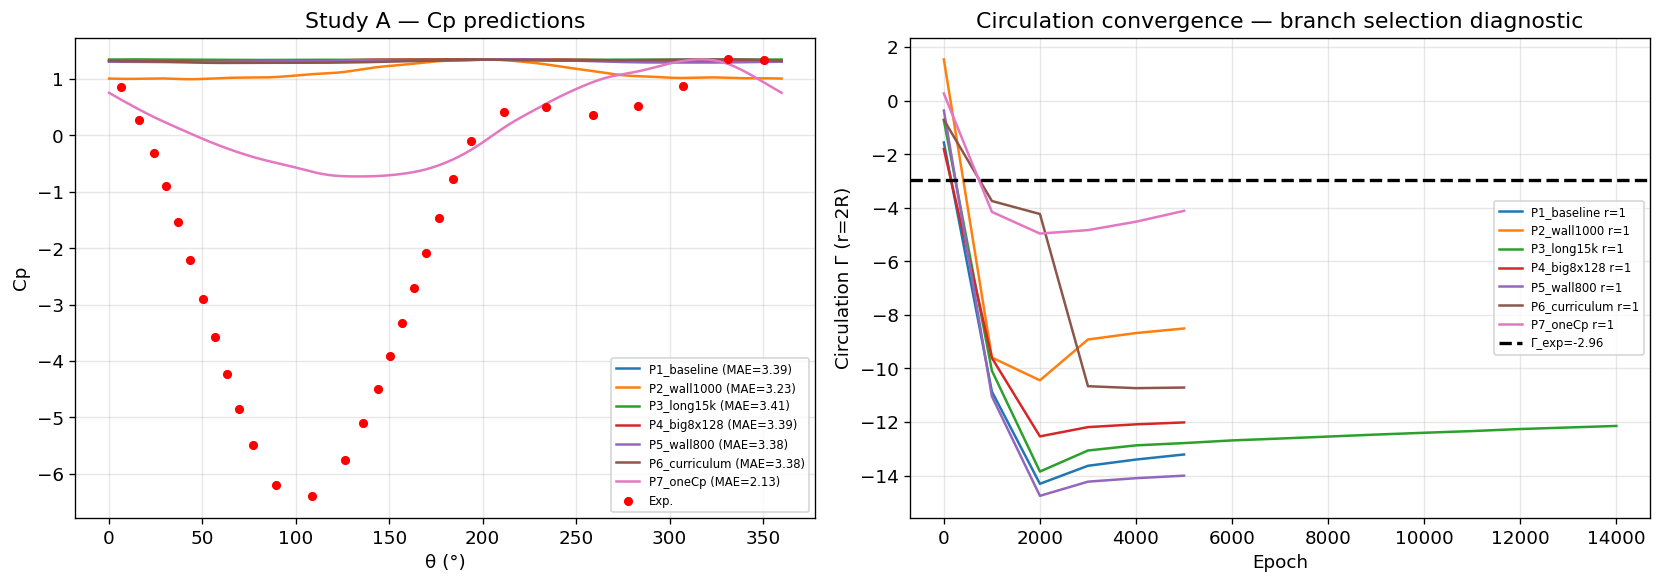

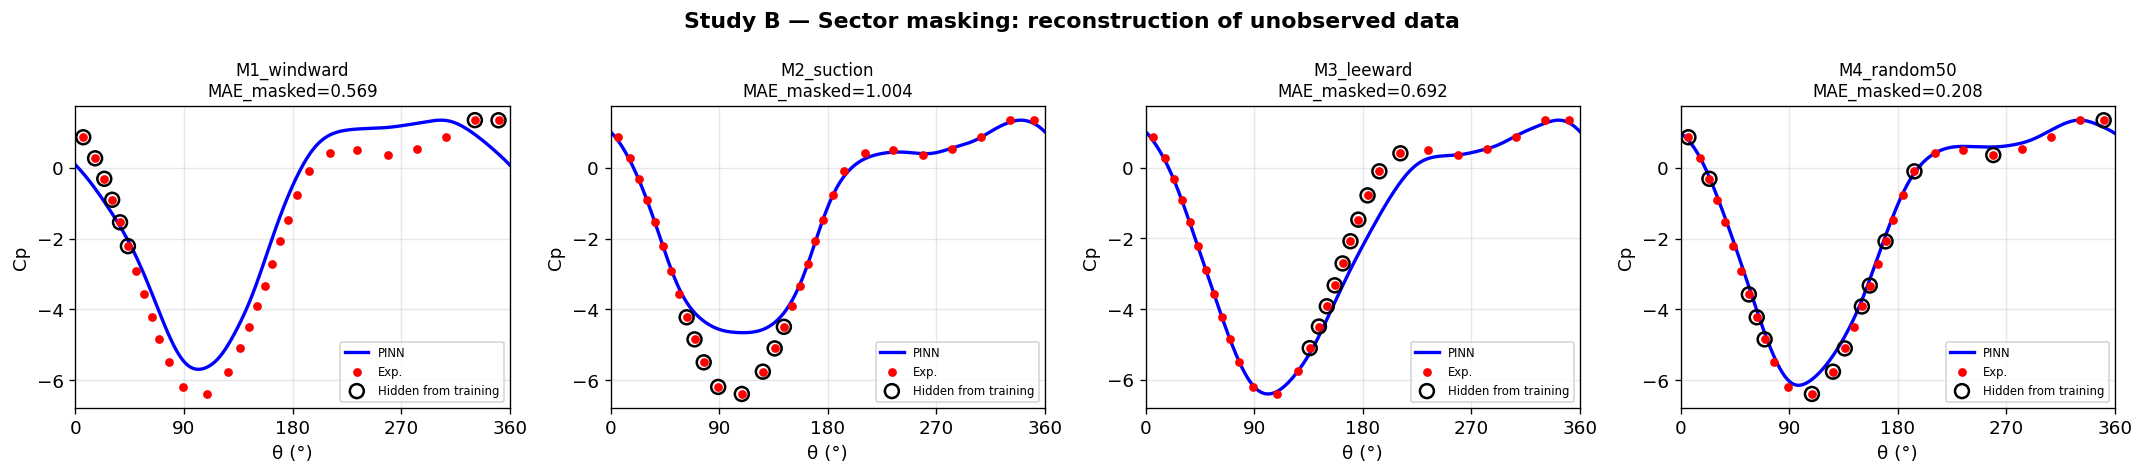

Figures saved ✓


In [7]:
# ── CELL 6: Analysis and figures ─────────────────────────────────
import json as _json, os as _os
if "all_results" not in dir() or len(all_results)==0:
    with open(RESULTS_FILE) as f: all_results=_json.load(f)

# ── Study A table: the circulation diagnostic is the headline ─────
print(f"\n{'='*75}")
print("  STUDY A — PHYSICS-ONLY FAILURE CHARACTERISATION")
print(f"  Kutta-Joukowski target: Γ_exp = {GAMMA_EXP:.3f}")
print(f"{'='*75}")
print(f"  {'Run':<15}{'MAE':>7}{'Γ(r=1)':>9}{'Γ(r=5)':>9}{'Γ5/Γex':>8}{'CL':>7}{'CD':>8}{'min':>5}")
print(f"  {'-'*63}")
for rid,r in all_results.items():
    if r.get("study")!="A": continue
    g5=r.get('gamma_r5',float('nan'))
    print(f"  {rid:<15}{r['mae']:>7.3f}{r['gamma']:>+9.3f}{g5:>+9.3f}"
          f"{g5/GAMMA_EXP:>8.2f}{r['CL']:>7.3f}{r['CD']:>8.3f}"
          f"{r.get('elapsed',0):>5.0f}")
print(f"  {'-'*63}")
print("  Interpretation: Γ(r=1) large (wall-driven swirl) but Γ(r=5)/Γ_exp ≈ 0")
print("  = swirl stays viscously confined; no outer-flow bound circulation")
print("  (steady RANS + velocity BCs do not select physical circulation branch)")
print("  P7 (one Cp point) shows minimum observation requirement.")

# ── Study B table ─────────────────────────────────────────────────
print(f"\n{'='*75}")
print("  STUDY B — SECTOR MASKING ROBUSTNESS")
print(f"{'='*75}")
print(f"  {'Run':<15}{'MAE_all':>9}{'MAE_obs':>9}{'MAE_mask':>10}{'CL':>8}{'CD':>8}")
print(f"  {'-'*59}")
for rid,r in all_results.items():
    if r.get("study")!="B": continue
    print(f"  {rid:<15}{r['mae']:>9.3f}{r.get('mae_observed',float('nan')):>9.3f}"
          f"{r.get('mae_masked',float('nan')):>10.3f}{r['CL']:>8.3f}{r['CD']:>8.3f}")
print(f"  {'-'*59}")
print(f"  Baseline (full 30 pts): MAE=0.056 | CL_exp={cl_ref:.3f} CD_exp={cd_ref:.3f}")

# ── Figure: Study A — Cp curves + circulation convergence ────────
runsA=[k for k,v in all_results.items() if v.get("study")=="A"]
if runsA:
    fig,axes=plt.subplots(1,2,figsize=(14,5))
    for rid in runsA:
        r=all_results[rid]
        if "Cp_pred" not in r:   # recovered entry — scalars only
            continue
        axes[0].plot(r["th_deg"],r["Cp_pred"],lw=1.5,label=f"{rid} (MAE={r['mae']:.2f})")
        gh=np.array(r.get("gamma_hist",[]))
        if len(gh)>0:
            axes[1].plot(gh[:,0],gh[:,1],lw=1.5,label=f"{rid} r=1")
            if gh.shape[1]>2:
                axes[1].plot(gh[:,0],gh[:,2],lw=1.5,ls="--",label=f"{rid} r=5")
    axes[0].scatter(theta_exp,cp_exp,color="red",s=20,zorder=5,label="Exp.")
    axes[0].set_xlabel("θ (°)"); axes[0].set_ylabel("Cp")
    axes[0].set_title("Study A — Cp predictions")
    axes[0].legend(fontsize=7); axes[0].grid(True,alpha=.3)
    axes[1].axhline(GAMMA_EXP,color="k",ls="--",lw=2,label=f"Γ_exp={GAMMA_EXP:.2f}")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Circulation Γ (r=2R)")
    axes[1].set_title("Circulation convergence — branch selection diagnostic")
    axes[1].legend(fontsize=7); axes[1].grid(True,alpha=.3)
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/closure_studyA.png",bbox_inches="tight",dpi=150)
    plt.show()

# ── Figure: Study B — Cp with hidden sectors shaded ──────────────
runsB=[k for k,v in all_results.items() if v.get("study")=="B"]
if runsB:
    fig,axes=plt.subplots(1,len(runsB),figsize=(4.5*len(runsB),4))
    if len(runsB)==1: axes=[axes]
    for ax,rid in zip(axes,runsB):
        r=all_results[rid]
        hidden_th=np.array(r["hidden_thetas"])
        ax.plot(r["th_deg"],r["Cp_pred"],"b-",lw=2,label="PINN")
        ax.scatter(theta_exp,cp_exp,color="red",s=18,zorder=5,label="Exp.")
        ax.scatter(hidden_th,np.interp(hidden_th,theta_exp,cp_exp),
                   facecolors="none",edgecolors="black",s=70,lw=1.5,
                   zorder=6,label="Hidden from training")
        ax.set_title(f"{rid}\nMAE_masked={r.get('mae_masked',float('nan')):.3f}",
                     fontsize=10)
        ax.set_xlabel("θ (°)"); ax.set_ylabel("Cp")
        ax.set_xlim([0,360]); ax.set_xticks([0,90,180,270,360])
        ax.legend(fontsize=7); ax.grid(True,alpha=.3)
    plt.suptitle("Study B — Sector masking: reconstruction of unobserved data",
                 fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/closure_studyB.png",bbox_inches="tight",dpi=150)
    plt.show()
print("Figures saved ✓")
